In [23]:
import numpy as np
import matplotlib.pyplot as plt

In [24]:
x = [5.2, 5.3, 5.4, 5.1, 10.1, 10.3, 9.9, 10.3, 3.2, 3.4, 3.3, 3.1]

(0.0, 12.0)

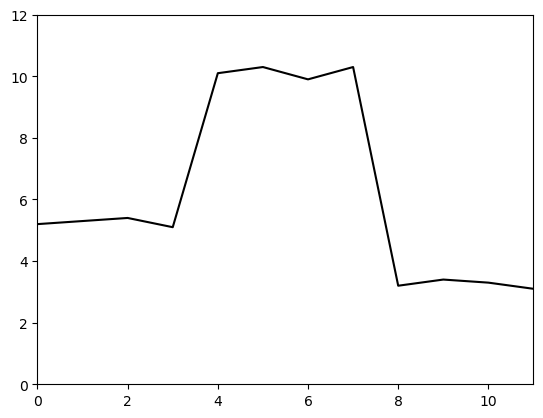

In [25]:
fig, ax = plt.subplots()
ax.plot(x, "k-")
ax.set_xlim(0, 11)
ax.set_ylim(0, 12)

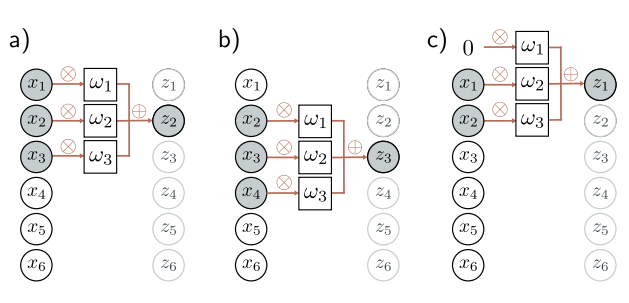

In [31]:
def conv_3_1_1_zp(x_in, omega):
    # Kernel size is 3, stride is 1, dilation is 1.
    # Same-padding (P=1) is used to maintain output length = input length.
    
    x_out = []
    kernel_size = 3
    padding = kernel_size // 2  # padding = 1 for kernel size 3
    
    N = len(x_in)
    
    # The outer loop iterates over the output indices (0 to N-1)
    for out_idx in range(N):
        z = 0
        
        # The inner loop iterates over the kernel weights
        for j in range(kernel_size):
            
            # Calculate the index into the (conceptually) padded input array
            # The input index into x_in should be: 
            # (output_index - padding) + kernel_weight_index 
            input_idx = (out_idx - padding) + j 
            
            # Zero-padding logic
            if input_idx < 0 or input_idx >= N:
                x = 0  # Zero-padding
            else:
                x = x_in[input_idx]
            
            weight = omega[j]
            term = x * weight
            
            z += term
            
        x_out.append(z) 
        
    return x_out

In [32]:
omega = [0.33,0.33,0.33]
h = conv_3_1_1_zp(x, omega)

print(f"Sum of output is {np.sum(h):3.3}, should be 71.1")

Sum of output is 71.1, should be 71.1


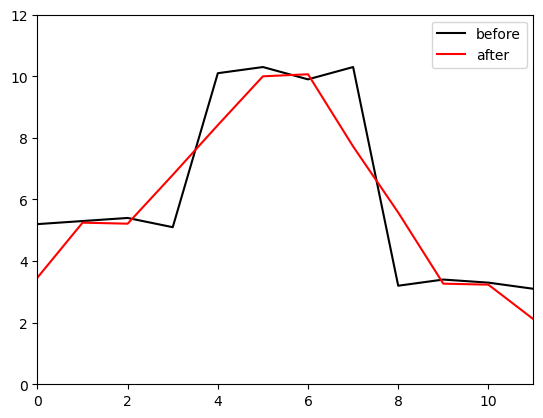

In [33]:
fig,ax = plt.subplots()
ax.plot(x, 'k-',label='before')
ax.plot(h, 'r-',label='after')
ax.set_xlim(0,11)
ax.set_ylim(0, 12)
ax.legend()
plt.show()

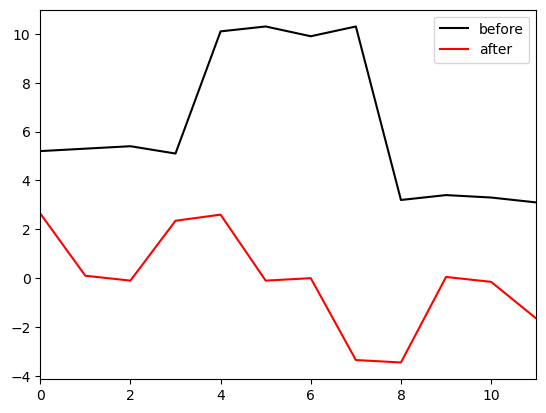

In [34]:
omega = [-0.5,0,0.5]
h2 = conv_3_1_1_zp(x, omega)

fig,ax = plt.subplots()
ax.plot(x, 'k-',label='before')
ax.plot(h2, 'r-',label='after')
ax.set_xlim(0,11)
# ax.set_ylim(0, 12)
ax.legend()
plt.show()

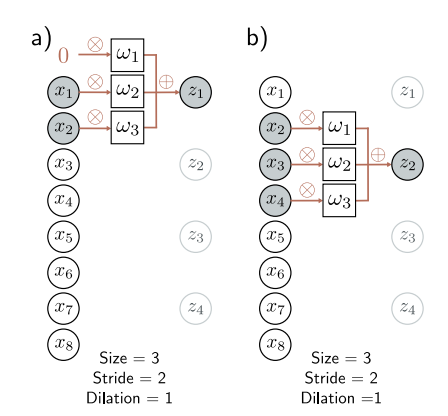

In [ ]:
def conv_3_2_1_zp(x_in, omega):
  # kernel size = 3
  # stride = 2
  # dilation = 1
  
  kernel_size = 3
  padding = kernel_size // 2
  N = len(x_in)
  
  x_out = []
  
  for outer_idx in range(0, N, 2):
    z = 0
    
    for kernel_idx in range(kernel_size):
      x_idx = (outer_idx - padding) + kernel_idx
      x = 0 if x_idx < 0 or x_idx >= len(x_in) else x_in[x_idx]
      
      z += x * omega[kernel_idx]
    
    x_out.append(z)
  
  return x_out

In [39]:
omega = [0.33,0.33,0.33]
h3 = conv_3_2_1_zp(x, omega)

# If you have done this right, the output length should be six and it should
# contain every other value from the original convolution with stride 1
print(h)
print(h3)

[3.4650000000000003, 5.247000000000001, 5.214, 6.798, 8.415000000000001, 9.999000000000002, 10.065000000000001, 7.722, 5.577, 3.267, 3.2340000000000004, 2.112]
[3.4650000000000003, 5.214, 8.415000000000001, 10.065000000000001, 5.577, 3.2340000000000004]


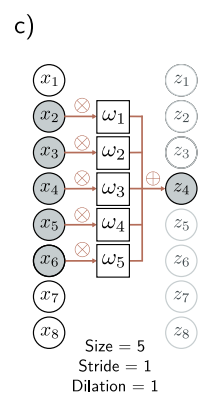

In [40]:
def conv_5_1_1_zp(x_in, omega):
  # kernel size = 5
  # stride = 1
  # dilation = 1
  
  kernel_size = 5
  padding = kernel_size // 2
  N = len(x_in)
  
  x_out = []
  
  for outer_idx in range(N):
    z = 0
    
    for kernel_idx in range(kernel_size):
      x_idx = (outer_idx - padding) + kernel_idx
      
      x = 0 if x_idx < 0 or x_idx >= len(x_in) else x_in[x_idx]
      
      z += x * omega[kernel_idx]
    
    x_out.append(z)
  
  return x_out

Sum of output is 69.6, should be 69.6


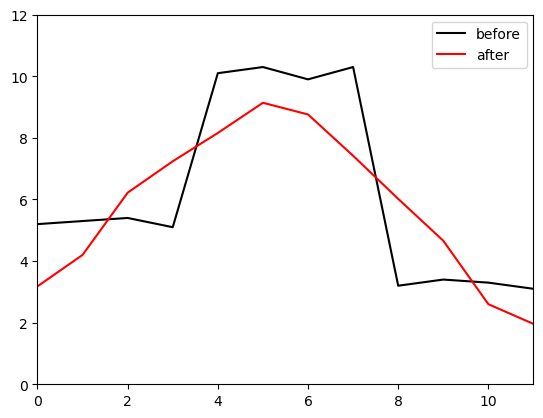

In [41]:
omega2 = [0.2, 0.2, 0.2, 0.2, 0.2]
h4 = conv_5_1_1_zp(x, omega2)

# Check that you have computed this correctly
print(f"Sum of output is {np.sum(h4):3.3}, should be 69.6")

# Draw the signal
fig,ax = plt.subplots()
ax.plot(x, 'k-',label='before')
ax.plot(h4, 'r-',label='after')
ax.set_xlim(0,11)
ax.set_ylim(0, 12)
ax.legend()
plt.show()
     

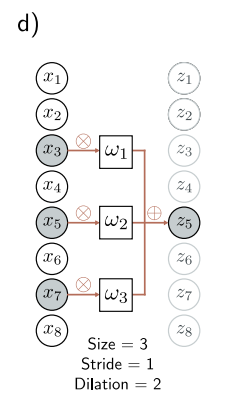

The formula for the Effective Kernel Size ($K_{\text{eff}}$) is:
$$K_{\text{eff}} = K + (K - 1) \times (D - 1)$$

In [50]:
def conv_3_1_2_zp(x_in, omega):
  # kernel_size = 3
  # stride = 1
  # dilation = 2
  
  kernel_size = 3
  dilation_rate = 2
  eff_kernel_size = kernel_size + ((kernel_size - 1) * (dilation_rate - 1))
  
  updated_omega = [omega[i // 2] if i % 2 == 0 else 0 for i in range(eff_kernel_size)]
  
  padding = eff_kernel_size // 2
  N = len(x_in)
  
  x_out = []
  
  for outer_idx in range(N):
    z = 0
    
    for kernel_idx in range(eff_kernel_size):
      x_idx = (outer_idx - padding) + kernel_idx
      
      x = 0 if x_idx < 0 or x_idx >= len(x_in) else x_in[x_idx]
      z += x * updated_omega[kernel_idx]
    
    x_out.append(z)
  
  return x_out

Sum of output is 68.3, should be 68.3


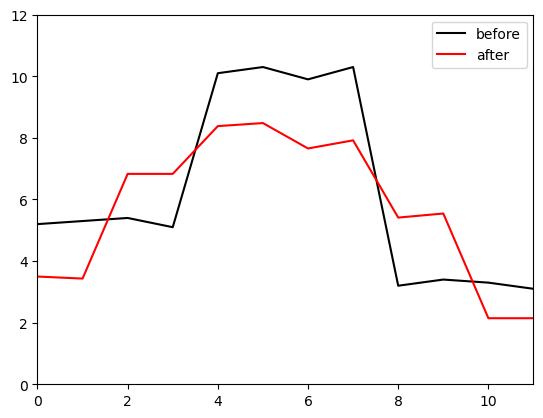

In [51]:
omega = [0.33,0.33,0.33]
h5 = conv_3_1_2_zp(x, omega)

# Check that you have computed this correctly
print(f"Sum of output is {np.sum(h5):3.3}, should be 68.3")

# Draw the signal
fig,ax = plt.subplots()
ax.plot(x, 'k-',label='before')
ax.plot(h5, 'r-',label='after')
ax.set_xlim(0,11)
ax.set_ylim(0, 12)
ax.legend()
plt.show()